## 1. Import necessary libraries


In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings(action = "ignore")

##  2. import Dataset

In [3]:
cars_data = pd.read_csv(filepath_or_buffer= "Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


# 3. Data Understanding

### 3.1 perform initial investigation on the data

In [4]:
cars_data.shape

(81, 5)

In [5]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [7]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## now let's check for the assumptions

## Test 1: linearity test

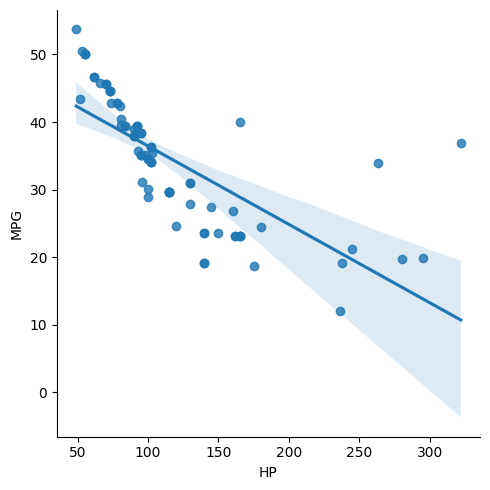

In [8]:
 sns.lmplot(data = cars_data,x= "HP",y="MPG")

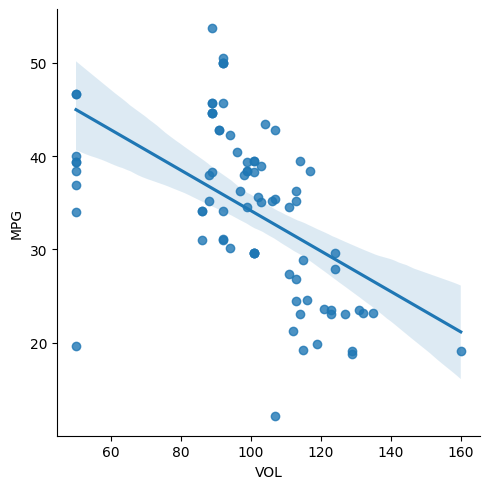

In [9]:
 sns.lmplot(data = cars_data,x= "VOL",y="MPG")

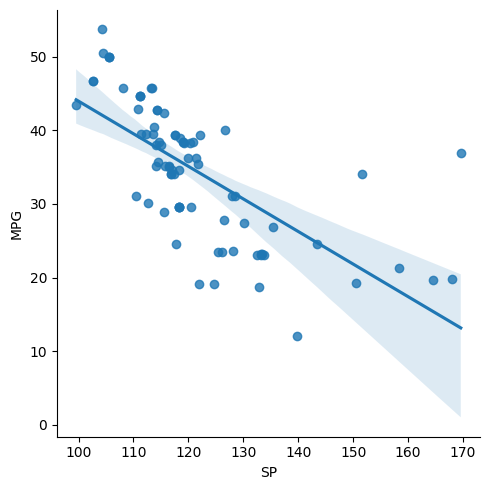

In [10]:
 sns.lmplot(data = cars_data,x= "SP",y="MPG")

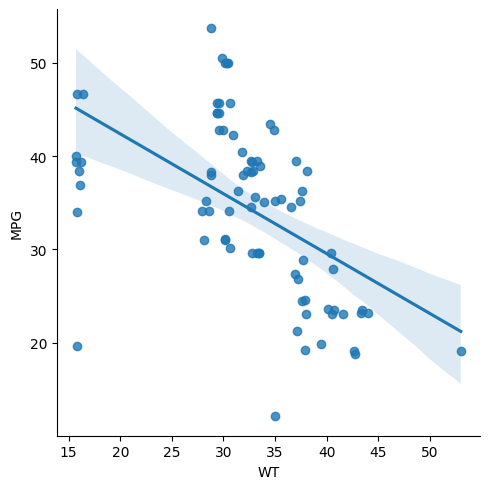

In [11]:
 sns.lmplot(data = cars_data,x= "WT",y="MPG")

#### Test 1 Linearity failed

## Test 2: Normality test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

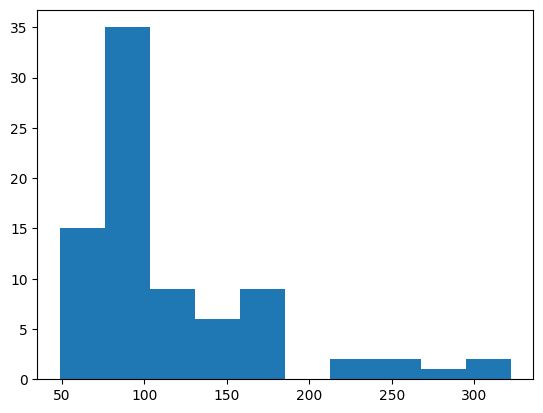

In [12]:
plt.hist(cars_data["HP"])

### here no line.. so we can use dist plot from seaborn for better view

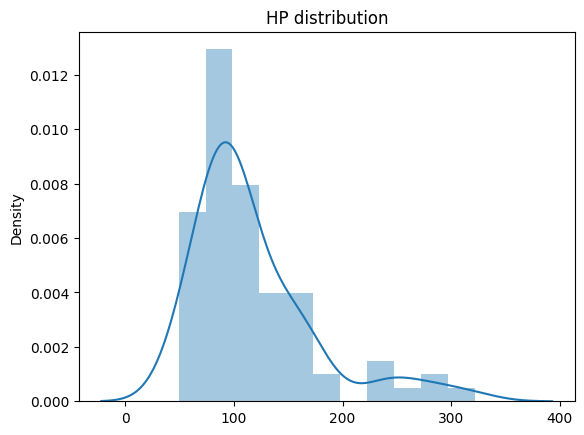

In [13]:
sns.distplot( x= cars_data["HP"])
plt.title("HP distribution")
plt.show()

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

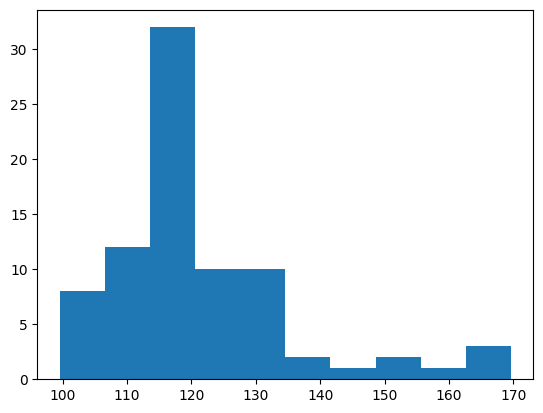

In [14]:
plt.hist(cars_data["SP"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

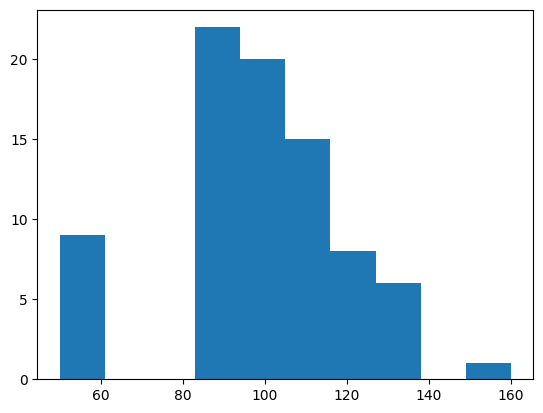

In [15]:
plt.hist(cars_data["VOL"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

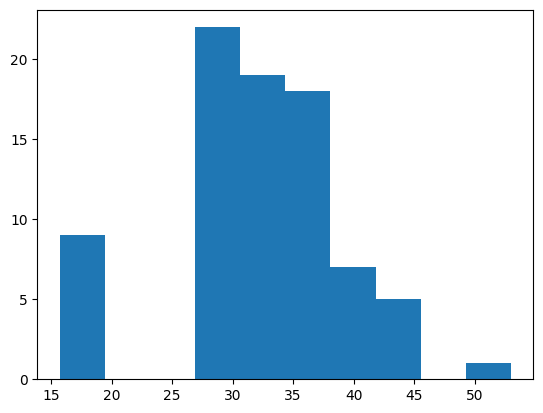

In [16]:
plt.hist(cars_data["WT"])

### there is no normality in any.. Test 2 Normality failed

## Test 3 Multi collinearity test

In [17]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


#### to make it colorful for betterview use seaborn

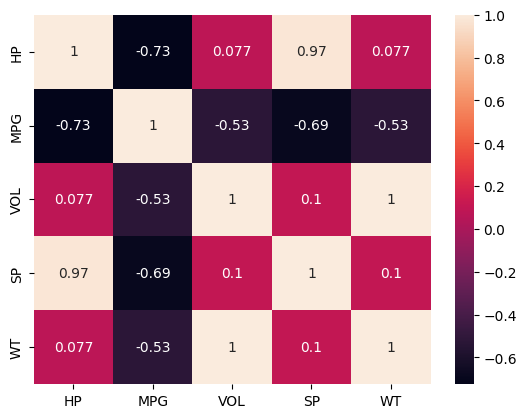

In [18]:
sns.heatmap(data = corr_matrix, annot= True )
plt.show()

### Note: very highly correlated is issue..so we can ignore 0.97..both are same

### There is multi collinearity in the data (more correlation)

## Test 4: No Autoregression

### Auto regression passed. Because there is no time based or weather based.

## Test 5 & 6 : can be done only after model is built, trained and tested

# step 4: Data preparation

### There is nothing to prepare..because all features are numeric. future engineering techniques can be applied later

In [19]:
x = cars_data[["HP","VOL","SP","WT"]]
x

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [20]:
y = cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

# Step 5 : Model Building

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size= 0.20, random_state=33,shuffle=True)

In [23]:
X_train

,HP,VOL,SP,WT
52,115,124,120.404312,40.398164
41,95,106,115.748847,35.027176
49,115,101,118.288996,33.458472
65,165,50,126.598513,15.712859
56,96,92,110.461264,30.147543
...,...,...,...,...
73,140,160,124.715241,52.997752
18,78,91,114.369293,29.929394
66,165,114,132.484609,37.979956
7,62,50,102.598513,15.847758


In [24]:
X_test

,HP,VOL,SP,WT
75,175,129,132.864163,42.778219
43,95,88,114.093383,28.343976
2,55,92,105.461264,30.193597
74,140,129,121.864163,42.618698
5,70,89,113.185353,29.591768
21,74,107,110.840817,34.908211
29,103,107,121.840817,35.549360
60,145,111,130.208698,36.888153
28,52,104,99.564907,34.483207
6,55,92,105.461264,30.308480


In [25]:
linear_model = LinearRegression()    #store in model

# Step 6:Model Training

In [26]:
linear_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
linear_model.intercept_

np.float64(17.665381121621692)

In [28]:
linear_model.coef_

array([-0.21733265, -0.32810369,  0.50944764,  0.3831729 ])

# Step 7: Model Testing

In [30]:
y_pred_train= linear_model.predict(X_train)
y_pred_train

array([28.80644196, 34.629229  , 32.6160823 , 35.91636391, 34.44185823,
       34.90237776, 46.32265294, 31.51179921, 37.52260028, 38.44780949,
       36.21030217, 38.37467538, 36.14926322, 24.8721867 , 40.63146663,
       40.58563662, 40.92760194, 26.0276729 , 34.20814893, 34.01370822,
       23.58744203, 45.79484416, 36.78890243, 35.38844917, 26.32601736,
       33.71902934, 47.38102573, 19.45027729, 37.11427386, 41.80652445,
       40.493221  , 15.17268121, 28.93605844, 22.54887526, 40.19996314,
       38.75259323, 37.50931597, 33.56681894, 39.56462523, 15.90071631,
       23.86235267, 29.06677307, 37.81020487, 22.99659311, 25.09838561,
       40.4384765 , 37.68174274, 47.21220479, 39.96792301, 34.93281611,
       36.21083577, 34.66199291, 36.77194118, 35.60857834, 36.84955693,
       40.48005198, 27.97848291, 24.16941866, 32.33868301, 18.58540634,
       40.58929721, 26.44853373, 46.12657361, 38.2522305 ])

In [31]:
y_pred_test= linear_model.predict(X_test)
y_pred_test

array([21.38557878, 37.13090198, 40.82290516, 23.32717377, 42.25164124,
       36.31914297, 35.86609084, 30.20169119, 36.17743634, 40.86692521,
       32.5223898 , 28.67628759, 27.3757065 , 30.32434557, 40.49900495,
       32.60774433, 41.91267602])

### note: check it with original result (mpg=y)...its not same

# Step 8: Model evaluation

In [37]:
error_train = y_train-y_pred_train
error_train

52    0.823494
41    0.523498
49   -2.986146
65    4.133636
56   -3.328274
        ...   
73    0.500934
18    2.200612
66   -3.345362
7     0.589981
20    0.158773
Name: MPG, Length: 64, dtype: float64

### note: it shows difference from actual output(error)

In [38]:
error_test = y_test-y_pred_test
error_test

75    -2.622742
43    -1.978175
2      9.190496
74    -4.240833
5      3.444681
21     6.509336
29    -0.461898
60    -2.847426
28     7.291998
6      9.146476
50    -2.892454
55    -0.820036
78     6.624294
70   -10.645839
13     4.153829
51    -2.977808
0     11.788005
Name: MPG, dtype: float64

In [49]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

### Evaluation metrics for train data

In [46]:
mean_absolute_error(y_train,y_pred_train)  #same units

2.9030238513531708

In [44]:
mean_squared_error(y_train,y_pred_train)  #squared output units

15.193541766865913

In [48]:
root_mean_squared_error(y_train,y_pred_train)  #normalising the units

3.8978893990037626

In [50]:
r2_score(y_train,y_pred_train)

0.7878129463927205

In [64]:
cars_data.head()

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,11.788005
1,55,50.013401,92,105.461264,30.466833,NaN
2,55,50.013401,92,105.461264,30.193597,9.190496
3,70,45.696322,92,113.461264,30.632114,NaN
4,53,50.504232,92,104.461264,29.889149,NaN


## To see Adjusted R2 score, we are using OLS technique from statsmodels formula

In [51]:
import statsmodels.formula.api as smf

In [71]:
linear_stats_model_train = smf.ols(formula= "MPG ~ HP", data = cars_data).fit()
linear_stats_model_train.predict(X_train)

52    34.708300
41    37.026718
49    34.708300
65    28.912256
56    36.910797
        ...    
73    31.810278
18    38.997373
66    28.912256
7     40.852107
20    37.374480
Length: 64, dtype: float64

In [73]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.5257 
Adjusted R2 Score: 0.5197


In [74]:
linear_stats_model_train = smf.ols(formula= "MPG ~ HP+VOL", data = cars_data).fit()
linear_stats_model_train.predict(X_train)

52    29.778112
41    35.485054
49    34.258463
65    38.691705
56    38.102195
        ...    
73    20.014663
18    40.277515
66    26.224641
7     50.024693
20    37.178726
Length: 64, dtype: float64

In [75]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.7507 
Adjusted R2 Score: 0.7443


In [76]:
linear_stats_model_train = smf.ols(formula= "MPG ~ HP+VOL+SP", data = cars_data).fit()
linear_stats_model_train.predict(X_train)

52    29.388754
41    35.287308
49    33.179201
65    36.457439
56    35.785195
        ...    
73    18.688920
18    41.273320
66    25.910107
7     48.132206
20    38.663674
Length: 64, dtype: float64

In [77]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.7704 
Adjusted R2 Score: 0.7614


In [78]:
linear_stats_model_train = smf.ols(formula= "MPG ~ HP+VOL+SP+WT", data = cars_data).fit()
linear_stats_model_train.predict(X_train)

52    29.198649
41    35.363133
49    33.311082
65    36.356525
56    35.815836
        ...    
73    18.717314
18    41.308610
66    26.097591
7     48.076219
20    38.577064
Length: 64, dtype: float64

In [79]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.7705 
Adjusted R2 Score: 0.7585


### note that adjusted r2 score only reduce or same when you add new feature. r2 score only incrases when you add new feature

### Evaluation Metrics for test data

In [80]:
mean_absolute_error(y_test,y_pred_test)

5.15507803609705

In [82]:
mean_squared_error(y_test,y_pred_test)

37.880245195991016

In [83]:
root_mean_squared_error(y_test,y_pred_test)

6.15469294083718

In [84]:
r2_score(y_test,y_pred_test)

0.686291029126436

In [85]:
linear_stats_model_test = smf.ols(formula = "MPG ~ HP", data = cars_data).fit()
linear_stats_model_test.predict(X_test)

75    27.753047
43    37.026718
2     41.663553
74    31.810278
5     39.924740
21    39.461056
29    36.099351
60    31.230674
28    42.011316
6     41.663553
50    34.708300
55    32.969487
78    17.552009
70    15.581354
13    39.576977
51    34.708300
0     42.359078
dtype: float64

In [86]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.7705 
Adjusted R2 Score: 0.7585


In [87]:
linear_stats_model_test = smf.ols(formula = "MPG ~ HP+VOL", data = cars_data).fit()
linear_stats_model_test.predict(X_test)

75    22.202382
43    38.991416
2     42.613384
74    26.053397
5     41.547343
21    37.600865
29    34.410024
60    29.009614
28    40.605897
6     42.613384
50    34.258463
55    28.127677
78    27.908863
70    26.038370
13    41.217256
51    34.258463
0     43.857952
dtype: float64

In [88]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.7705 
Adjusted R2 Score: 0.7585


In [89]:
linear_stats_model_test = smf.ols(formula = "MPG ~ HP+VOL+SP", data = cars_data).fit()
linear_stats_model_test.predict(X_test)

75    20.970369
43    38.253745
2     42.256794
74    23.797784
5     42.855903
21    37.460010
29    35.872824
60    29.737290
28    38.094668
6     42.256794
50    33.179201
55    28.692138
78    26.216856
70    27.911446
13    41.434470
51    33.179201
0     43.590769
dtype: float64

In [90]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.7705 
Adjusted R2 Score: 0.7585


In [91]:
linear_stats_model_test = smf.ols(formula = "MPG ~ HP+VOL+SP+WT", data = cars_data).fit()
linear_stats_model_test.predict(X_test)

75    21.074613
43    38.079985
2     42.279341
74    23.849347
5     43.020619
21    37.351997
29    36.002853
60    29.876858
28    38.248612
6     42.325361
50    33.213134
55    28.567226
78    26.136453
70    27.808465
13    41.527579
51    33.302365
0     43.441935
dtype: float64

In [92]:
print("R2_score:",linear_stats_model_train.rsquared.round(4),"\nAdjusted R2 Score:",linear_stats_model_train.rsquared_adj.round(4))

R2_score: 0.7705 
Adjusted R2 Score: 0.7585


# Let's now perform homoscadasticity test- Test 5

In [36]:
#plt.scatter(data = cars_data, x = "HP", y= error) ----it shows value eror..bcz we didn't add error coloumn in cars data

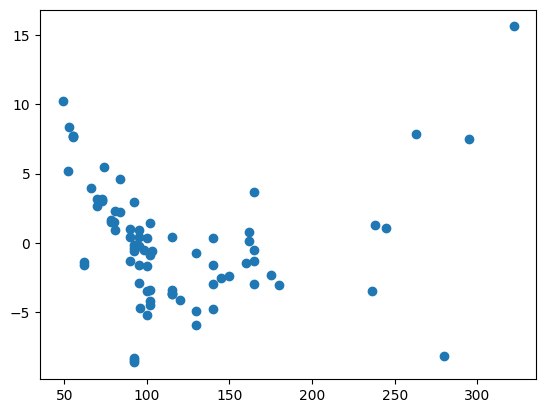

In [48]:
plt.scatter(data = cars_data, x = "HP", y= "error") 

### otherwise we can use seaborn..it won't show any error even without adding coloumn

In [50]:
del cars_data["error"]

In [51]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


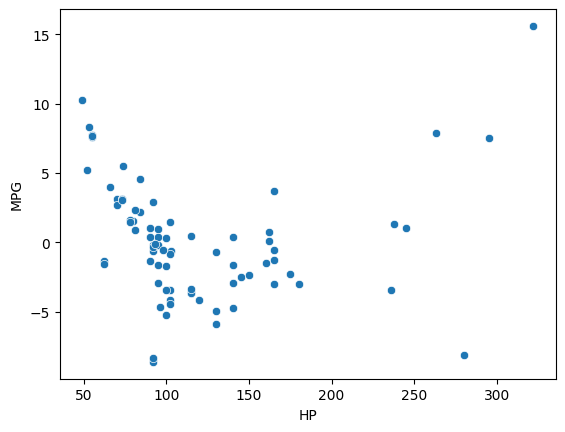

In [53]:
sns.scatterplot(data = cars_data,x= "HP", y= error)
plt.show()

### There is no similar variences in error

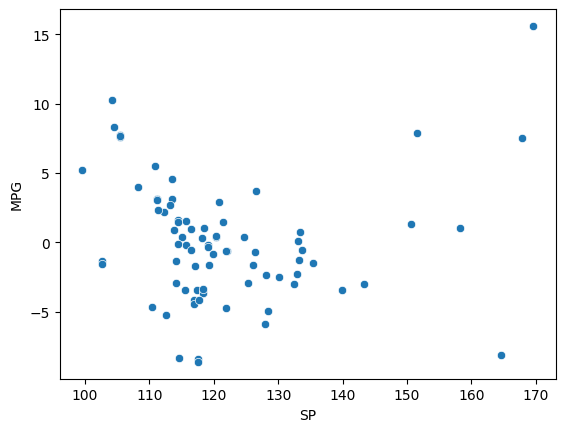

In [54]:
sns.scatterplot(data = cars_data,x= "SP", y= error)
plt.show()

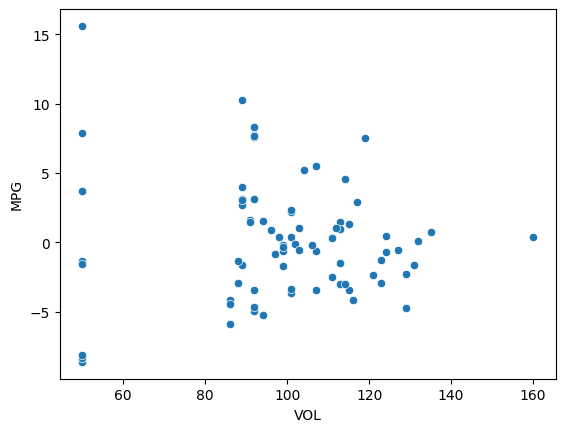

In [55]:
sns.scatterplot(data = cars_data,x= "VOL", y= error)
plt.show()

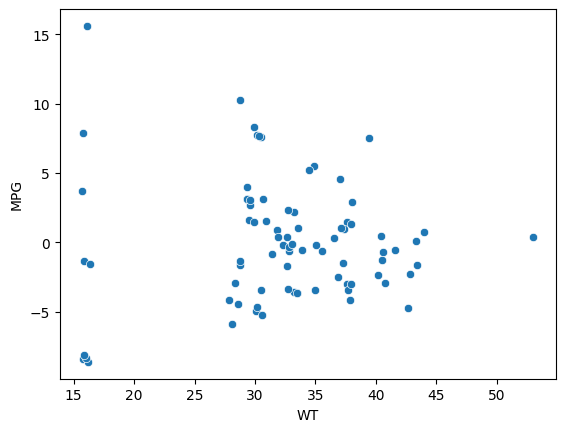

In [56]:
sns.scatterplot(data = cars_data,x= "WT", y= error)
plt.show()

### HP, SP ---- convey same----so one coloumn in enough 
### VOL, WT ---- convey same----so one coloumn in enough

## Test 5: Homoscadasticity test failed

# Tear 6: Zero residual mean test
we can take scatter plot or lm plot

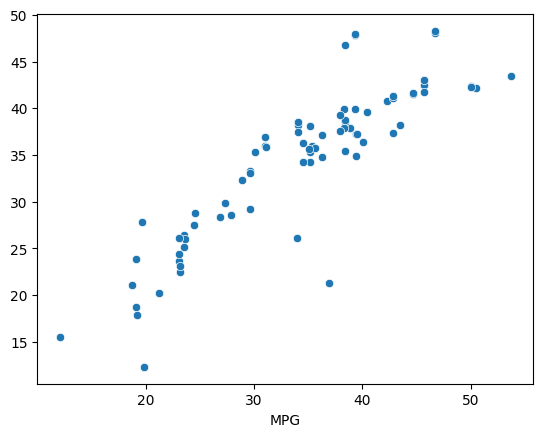

In [58]:
sns.scatterplot(x = cars_data["MPG"], y= y_pred)
plt.show()

## Test 6: zero residual mean test is also failed

# Step 9: Model Deployment

In [59]:
from pickle import dump

In [60]:
dump(obj = linear_model,file = open(file ="linear_intelligence_file.pkl",mode = 'wb'))

In [61]:
from pickle import load

In [62]:
linear_intel_pkl = load(file = open(file ="linear_intelligence_file.pkl",mode = 'rb'))
linear_intel_pkl

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
linear_intel_pkl.predict(x)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## The end